In [1]:
print("Employee Attrition Project Started!")

Employee Attrition Project Started!


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1470
Number of columns: 35


In [6]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [8]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [9]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [10]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [11]:
df["Attrition"].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

In [12]:
df.sample(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1317,27,No,Travel_Frequently,1297,Research & Development,5,2,Life Sciences,1,1850,...,3,80,0,6,3,2,5,4,0,2
498,22,No,Travel_Rarely,604,Research & Development,6,1,Medical,1,675,...,4,80,0,3,3,3,2,2,2,2
1402,31,No,Travel_Rarely,1276,Research & Development,2,1,Medical,1,1974,...,3,80,3,1,4,3,1,0,0,0
768,40,No,Travel_Rarely,300,Sales,26,3,Marketing,1,1066,...,2,80,1,8,3,2,7,7,7,5
715,33,No,Travel_Frequently,827,Research & Development,1,4,Other,1,998,...,1,80,1,6,2,3,6,5,1,2


In [13]:
ml_df = df.copy()

In [14]:
ml_df = ml_df.drop(columns=[
    "EmployeeCount",
    "Over18",
    "StandardHours",
    "EmployeeNumber"
])

In [15]:
print("Number of columns:", ml_df.shape[1])
print(ml_df.columns.tolist())

Number of columns: 31
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [16]:
X = ml_df.drop(columns=["Attrition"])

In [17]:
y = ml_df["Attrition"]

In [18]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1470, 30)
y shape: (1470,)


In [19]:
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [20]:
numerical_columns = X.select_dtypes(include=["number"]).columns.tolist()

print("Number of numerical columns:", len(numerical_columns))
print(numerical_columns)

Number of numerical columns: 23
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [23]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1176, 30)
X_test: (294, 30)
y_train: (1176,)
y_test: (294,)


In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ],
    remainder="passthrough"
)

In [26]:
X_train_processed = preprocessor.fit_transform(X_train)

In [27]:
X_test_processed = preprocessor.transform(X_test)

In [28]:
print("Original X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)

print("Original X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)

Original X_train shape: (1176, 30)
Processed X_train shape: (1176, 51)
Original X_test shape: (294, 30)
Processed X_test shape: (294, 51)


In [30]:
y_train_encoded = y_train.map({"Yes": 1, "No": 0})
y_test_encoded = y_test.map({"Yes": 1, "No": 0})

In [31]:
from sklearn.linear_model import LogisticRegression

In [32]:
logistic_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

In [33]:
logistic_model.fit(X_train_processed, y_train_encoded)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,3000
,multi_class,'deprecated'


In [34]:
y_pred_logistic = logistic_model.predict(X_test_processed)

In [35]:
print("Predicted:", y_pred_logistic[:10])
print("Actual:   ", y_test_encoded.iloc[:10].values)

Predicted: [0 0 0 0 1 1 0 0 0 0]
Actual:    [0 0 0 0 1 0 0 0 0 0]


In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [37]:
logistic_accuracy = accuracy_score(y_test_encoded, y_pred_logistic)
logistic_precision = precision_score(y_test_encoded, y_pred_logistic)
logistic_recall = recall_score(y_test_encoded, y_pred_logistic)
logistic_f1 = f1_score(y_test_encoded, y_pred_logistic)

logistic_probabilities = logistic_model.predict_proba(X_test_processed)[:, 1]
logistic_roc_auc = roc_auc_score(
    y_test_encoded,
    logistic_probabilities
)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall   :", logistic_recall)
print("F1 Score :", logistic_f1)
print("ROC-AUC  :", logistic_roc_auc)

Logistic Regression Results
---------------------------
Accuracy : 0.7517006802721088
Precision: 0.3488372093023256
Recall   : 0.6382978723404256
F1 Score : 0.45112781954887216
ROC-AUC  : 0.8011025928159187


In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

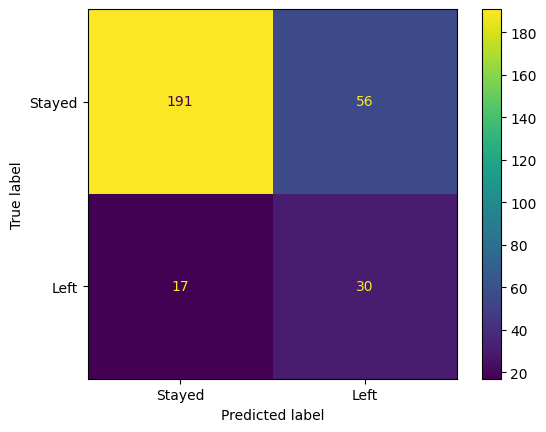

In [39]:
cm = confusion_matrix(y_test_encoded, y_pred_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Left"]
)

disp.plot()

In [40]:
from sklearn.tree import DecisionTreeClassifier

In [41]:
decision_tree = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

In [42]:
decision_tree.fit(X_train_processed, y_train_encoded)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [43]:
y_pred_dt = decision_tree.predict(X_test_processed)

In [44]:
dt_accuracy = accuracy_score(y_test_encoded, y_pred_dt)
dt_precision = precision_score(y_test_encoded, y_pred_dt)
dt_recall = recall_score(y_test_encoded, y_pred_dt)
dt_f1 = f1_score(y_test_encoded, y_pred_dt)

dt_probabilities = decision_tree.predict_proba(X_test_processed)[:, 1]

dt_roc_auc = roc_auc_score(
    y_test_encoded,
    dt_probabilities
)

print("Decision Tree Results")
print("--------------------")
print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)
print("ROC-AUC  :", dt_roc_auc)

Decision Tree Results
--------------------
Accuracy : 0.782312925170068
Precision: 0.373134328358209
Recall   : 0.5319148936170213
F1 Score : 0.43859649122807015
ROC-AUC  : 0.662847790507365


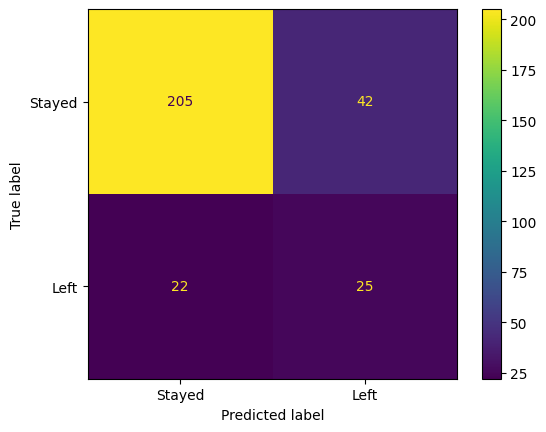

In [45]:
cm_dt = confusion_matrix(y_test_encoded, y_pred_dt)

disp_dt = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=["Stayed", "Left"]
)

disp_dt.plot()

In [46]:
from sklearn.ensemble import RandomForestClassifier

In [47]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight="balanced",
    random_state=42
)

In [48]:
random_forest.fit(
    X_train_processed,
    y_train_encoded
)

,n_estimators,200
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
y_pred_rf = random_forest.predict(X_test_processed)

In [50]:
rf_accuracy = accuracy_score(y_test_encoded, y_pred_rf)
rf_precision = precision_score(y_test_encoded, y_pred_rf)
rf_recall = recall_score(y_test_encoded, y_pred_rf)
rf_f1 = f1_score(y_test_encoded, y_pred_rf)

rf_probabilities = random_forest.predict_proba(X_test_processed)[:, 1]

rf_roc_auc = roc_auc_score(
    y_test_encoded,
    rf_probabilities
)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_roc_auc)

Random Forest Results
---------------------
Accuracy : 0.8299319727891157
Precision: 0.43478260869565216
Recall   : 0.2127659574468085
F1 Score : 0.2857142857142857
ROC-AUC  : 0.7908519252304247


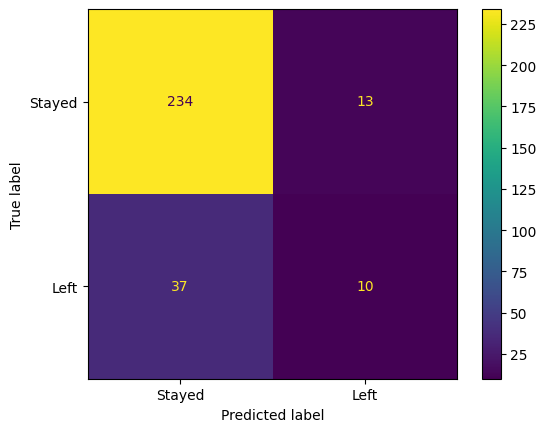

In [51]:
cm_rf = confusion_matrix(y_test_encoded, y_pred_rf)

disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Stayed", "Left"]
)

disp_rf.plot()

In [52]:
import xgboost as xgb
print(xgb.__version__)

3.2.0


In [53]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

In [54]:
xgb_model.fit(
    X_train_processed,
    y_train_encoded
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [55]:
y_pred_xgb = xgb_model.predict(X_test_processed)

In [56]:
xgb_accuracy = accuracy_score(y_test_encoded, y_pred_xgb)
xgb_precision = precision_score(y_test_encoded, y_pred_xgb)
xgb_recall = recall_score(y_test_encoded, y_pred_xgb)
xgb_f1 = f1_score(y_test_encoded, y_pred_xgb)

xgb_probabilities = xgb_model.predict_proba(X_test_processed)[:, 1]

xgb_roc_auc = roc_auc_score(
    y_test_encoded,
    xgb_probabilities
)

print("XGBoost Results")
print("----------------")
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)
print("ROC-AUC  :", xgb_roc_auc)

XGBoost Results
----------------
Accuracy : 0.8673469387755102
Precision: 0.75
Recall   : 0.2553191489361702
F1 Score : 0.38095238095238093
ROC-AUC  : 0.7862003617882678


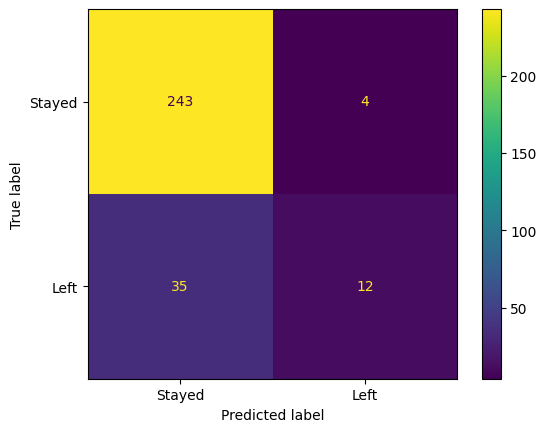

In [57]:
cm_xgb = confusion_matrix(y_test_encoded, y_pred_xgb)

disp_xgb = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["Stayed", "Left"]
)

disp_xgb.plot()

In [60]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        logistic_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        logistic_precision,
        dt_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        logistic_recall,
        dt_recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        logistic_f1,
        dt_f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        dt_roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})

model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.752,0.349,0.638,0.451,0.801
1,Decision Tree,0.782,0.373,0.532,0.439,0.663
2,Random Forest,0.830,0.435,0.213,0.286,0.791
3,XGBoost,0.867,0.750,0.255,0.381,0.786


In [61]:
best_model_name = "Logistic Regression"

print("Selected Model:", best_model_name)
print("F1 Score:", logistic_f1)
print("ROC-AUC:", logistic_roc_auc)
print("Recall:", logistic_recall)

Selected Model: Logistic Regression
F1 Score: 0.45112781954887216
ROC-AUC: 0.8011025928159187
Recall: 0.6382978723404256


In [62]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 51
['categorical__BusinessTravel_Non-Travel'
 'categorical__BusinessTravel_Travel_Frequently'
 'categorical__BusinessTravel_Travel_Rarely'
 'categorical__Department_Human Resources'
 'categorical__Department_Research & Development'
 'categorical__Department_Sales'
 'categorical__EducationField_Human Resources'
 'categorical__EducationField_Life Sciences'
 'categorical__EducationField_Marketing'
 'categorical__EducationField_Medical' 'categorical__EducationField_Other'
 'categorical__EducationField_Technical Degree'
 'categorical__Gender_Female' 'categorical__Gender_Male'
 'categorical__JobRole_Healthcare Representative'
 'categorical__JobRole_Human Resources'
 'categorical__JobRole_Laboratory Technician'
 'categorical__JobRole_Manager'
 'categorical__JobRole_Manufacturing Director'
 'categorical__JobRole_Research Director'
 'categorical__JobRole_Research Scientist'
 'categorical__JobRole_Sales Executive'
 'categorical__JobRole_Sales Representative'
 'categorical__Ma

In [63]:
coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": logistic_model.coef_[0]
})

coefficient_df["Absolute_Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

coefficient_df.head(15)

,Feature,Coefficient,Absolute_Coefficient
16,categorical__JobRole_Laboratory Technician,1.413237,1.413237
27,categorical__OverTime_Yes,1.413221,1.413221
19,categorical__JobRole_Research Director,-1.311328,1.311328
22,categorical__JobRole_Sales Representative,1.238003,1.238003
1,categorical__BusinessTravel_Travel_Frequently,1.228570,1.228570
6,categorical__EducationField_Human Resources,0.913251,0.913251
25,categorical__MaritalStatus_Single,0.884820,0.884820
5,categorical__Department_Sales,0.843055,0.843055
13,categorical__Gender_Male,0.752041,0.752041
41,remainder__PerformanceRating,0.624322,0.624322


In [64]:
import shap

print("SHAP version:", shap.__version__)

C:\Users\NAVYA\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.49.1


In [65]:
explainer = shap.LinearExplainer(
    logistic_model,
    X_train_processed
)

print("SHAP explainer created successfully!")

SHAP explainer created successfully!


In [66]:
shap_values = explainer(X_test_processed)

print("SHAP values calculated successfully!")
print("SHAP values shape:", shap_values.values.shape)

SHAP values calculated successfully!
SHAP values shape: (294, 51)


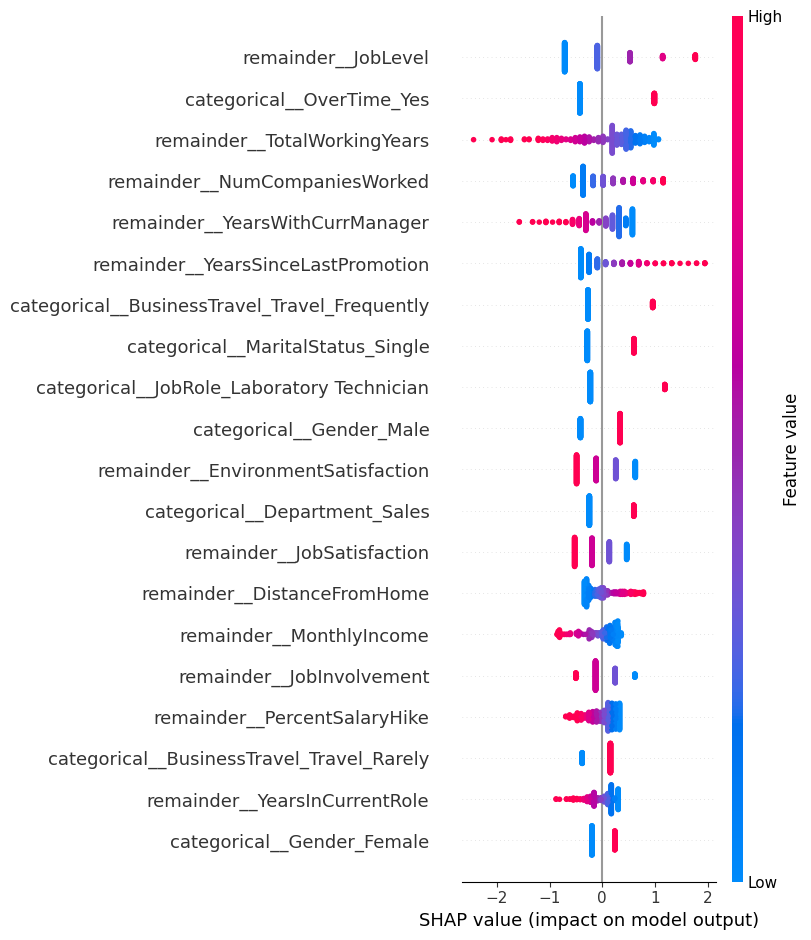

In [67]:
shap.summary_plot(
    shap_values.values,
    X_test_processed,
    feature_names=feature_names,
    show=True
)

In [68]:
employee_index = 0

employee_shap = shap_values[employee_index]

print("Employee index:", employee_index)
print("Actual Attrition:", y_test.iloc[employee_index])
print("Predicted Attrition:", y_pred_logistic[employee_index])

Employee index: 0
Actual Attrition: No
Predicted Attrition: 0


In [69]:
employee_shap_df = pd.DataFrame({
    "Feature": feature_names,
    "SHAP_Value": employee_shap.values
})

employee_shap_df["Absolute_SHAP"] = (
    employee_shap_df["SHAP_Value"].abs()
)

employee_shap_df = employee_shap_df.sort_values(
    by="Absolute_SHAP",
    ascending=False
)

employee_shap_df.head(15).round(4)

,Feature,SHAP_Value,Absolute_SHAP
22,categorical__JobRole_Sales Representative,1.2132,1.2132
44,remainder__TotalWorkingYears,0.9799,0.9799
35,remainder__JobLevel,-0.7128,0.7128
5,categorical__Department_Sales,0.5986,0.5986
50,remainder__YearsWithCurrManager,0.5735,0.5735
0,categorical__BusinessTravel_Non-Travel,-0.5368,0.5368
32,remainder__EnvironmentSatisfaction,-0.4867,0.4867
27,categorical__OverTime_Yes,-0.4240,0.4240
13,categorical__Gender_Male,-0.4136,0.4136
49,remainder__YearsSinceLastPromotion,-0.4065,0.4065


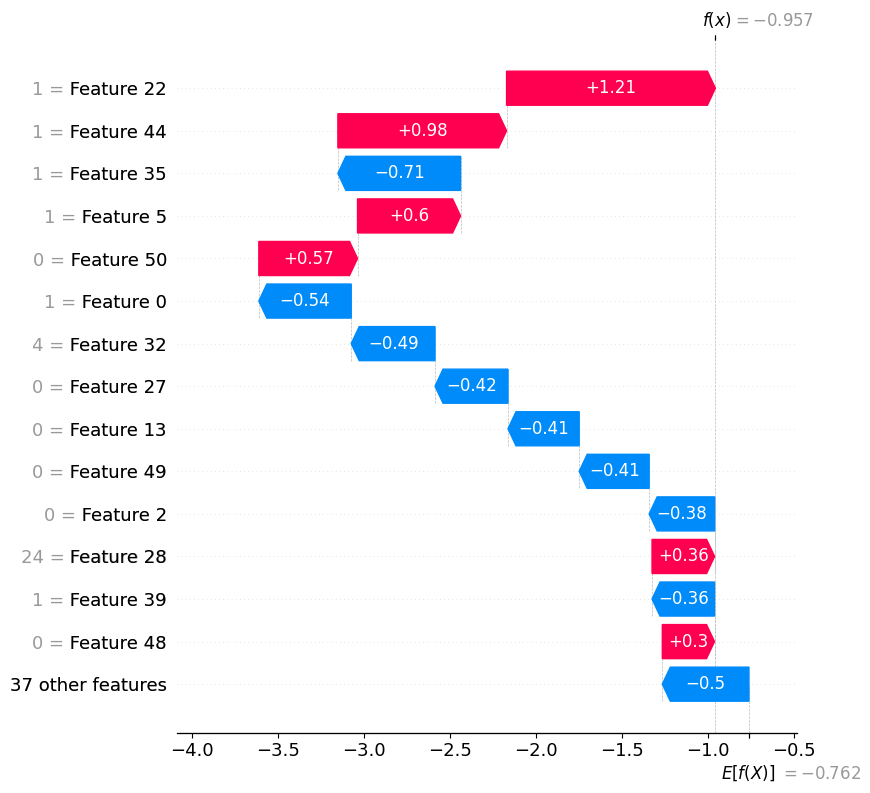

In [70]:
shap.plots.waterfall(employee_shap, max_display=15)

In [71]:
import joblib
import os

In [72]:
os.makedirs("../models", exist_ok=True)

In [73]:
joblib.dump(
    logistic_model,
    "../models/logistic_regression_model.pkl"
)

print("Logistic Regression model saved successfully!")

Logistic Regression model saved successfully!


In [74]:
joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

print("Preprocessor saved successfully!")

Preprocessor saved successfully!


In [75]:
print(os.listdir("../models"))

['logistic_regression_model.pkl', 'preprocessor.pkl']


In [77]:
import joblib

joblib.dump(
    explainer,
    "../models/shap_explainer.pkl"
)

print("SHAP explainer saved successfully!")

SHAP explainer saved successfully!
